# 1. Analiza korelacyjna EDA

1. Konfiguracja

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ustawienia stylu wykresów
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

2. Definicja funkcji analizującej dane

In [14]:
def perform_eda(filepath='/dane_obrobka_cnc.csv'):
    print("Wczytywanie danych...")
    df = pd.read_csv(filepath)

    # OBSŁUGA ANOMALII
    # Błędy czujnika zastępujemy wartością Nan, żeby zapobiec popsuciu korelacji
    df_clean = df.copy()
    df_clean['Temp_Chlodziwa_Mean_C'] = df_clean['Temp_Chlodziwa_Mean_C'].replace(-99.0, np.nan)

    # Odrzucamy kolumny z ID
    cols_to_drop = ['ID_Czesci', 'ID_Narzedzia', 'Awaria_Narzedzia', 'Klasa_Jakosci']
    df_numeric = df_clean.drop(columns=cols_to_drop)

    # MACIERZ KORELACJI
    print("Generowanie macierzy korelacji...")
    plt.figure(figsize=(12, 10))
    corr_matrix = df_numeric.corr(method='pearson')

    # Tworzenie maski dla górnego trójkąta (aby wykres był czytelniejszy)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
                vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .75})

    plt.tight_layout()
    plt.savefig('macierz_korelacji.png')
    plt.show()

    # WIZUALIZACJA ZALEŻNOŚCI FIZYCZNYCH
    print("Generowanie wykresów zależności...")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Wykres A: Wpływ zużycia narzędzia na wibracje (Nieliniowość)
    sns.scatterplot(data=df_clean, x='Zuzycie_Narzedzia_VB', y='Wibracje_Wrzeciona_RMS_g',
                    alpha=0.3, ax=axes[0], color='crimson')
    axes[0].set_title('A: Wpływ Zużycia Ostrza na Wibracje')
    axes[0].set_xlabel('Zużycie Narzędzia VB [mm]')
    axes[0].set_ylabel('Wibracje RMS [g]')

    # Wykres B: Zależność posuwu i chropowatości (Model kinematyczny)
    sns.scatterplot(data=df_clean, x='Posuw_f', y='Chropowatosc_Ra',
                    hue='Klasa_Jakosci', palette={'OK': 'green', 'Do_Poprawy': 'orange', 'Zlom': 'red'},
                    alpha=0.5, ax=axes[1])
    axes[1].set_title('B: Wpływ Posuwu na Chropowatość Ra')
    axes[1].set_xlabel('Posuw f [mm/obr]')
    axes[1].set_ylabel('Chropowatość Ra [µm]')

    # Wykres C: Zużycie narzędzia w funkcji wyprodukowanych sztuk (Cykl życia z rozkładu Weibulla)
    # Wybieramy jedno losowe narzędzie (np. narzędzie nr 3)
    df_tool_3 = df_clean[df_clean['ID_Narzedzia'] == 3]
    sns.lineplot(data=df_tool_3, x='ID_Czesci', y='Zuzycie_Narzedzia_VB',
                 ax=axes[2], color='navy', linewidth=2)
    axes[2].set_title('C: Krzywa Zużycia Narzędzia nr 3 w czasie')
    axes[2].set_xlabel('Kolejna wyprodukowana sztuka (ID)')
    axes[2].set_ylabel('Zużycie Narzędzia VB [mm]')

    plt.tight_layout()
    plt.savefig('wykresy_eda.png')
    plt.show()

    print("EDA zakończone. Wykresy zapisane.")

# **Dodatkowa analiza**

In [15]:
def generate_eda(filepath='/dane_obrobka_cnc.csv'):
    print("Wczytywanie danych...")
    df = pd.read_csv(filepath)

    # Oczyszczenie danych z błędu czujnika (-99.0)
    df_clean = df.copy()
    df_clean['Temp_Chlodziwa_Mean_C'] = df_clean['Temp_Chlodziwa_Mean_C'].replace(-99.0, np.nan)

    # Definicja kolejności klas dla czytelności wykresów
    quality_order = ['OK', 'Do_Poprawy', 'Zlom']
    palette = {'OK': '#2ca02c', 'Do_Poprawy': '#ff7f0e', 'Zlom': '#d62728'}

    print("Generowanie rozkładu zmiennych w klasach jakości")
    # ROZKŁADY ZMIENNYCH W KLASACH JAKOŚCI
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Separowalność Klas Jakości na podstawie Odczytów z Czujników', fontsize=16, y=1.05)

    # Wibracje vs Jakość
    sns.boxplot(data=df_clean, x='Klasa_Jakosci', y='Wibracje_Wrzeciona_RMS_g',
                order=quality_order, palette=palette, ax=axes[0])
    axes[0].set_title('Wpływ Wibracji na Klasę Jakości')
    axes[0].set_xlabel('Klasa Jakości')
    axes[0].set_ylabel('Wibracje Wrzeciona RMS [g]')

    # Temperatura vs Jakość
    sns.boxplot(data=df_clean, x='Klasa_Jakosci', y='Temp_Narzedzia_Max_C',
                order=quality_order, palette=palette, ax=axes[1])
    axes[1].set_title('Maksymalna Temperatura a Jakość Detalu')
    axes[1].set_xlabel('Klasa Jakości')
    axes[1].set_ylabel('Maksymalna Temp. Narzędzia [°C]')

    # Zużycie narzędzia vs Jakość
    sns.boxplot(data=df_clean, x='Klasa_Jakosci', y='Zuzycie_Narzedzia_VB',
                order=quality_order, palette=palette, ax=axes[2])
    axes[2].set_title('Poziom Zużycia Ostrza a Jakość Detalu')
    axes[2].set_xlabel('Klasa Jakości')
    axes[2].set_ylabel('Zużycie Narzędzia VB [mm]')

    plt.tight_layout()
    plt.savefig('boxplots_jakosc.png', bbox_inches='tight')
    plt.show()

    print("Generowanie macierzy korelacji Spearmana")

    # MACIERZ KORELACJI SPEARMANA (Dla relacji nieliniowych)
    cols_to_drop = ['ID_Czesci', 'ID_Narzedzia', 'Awaria_Narzedzia', 'Klasa_Jakosci']
    df_numeric = df_clean.drop(columns=cols_to_drop)

    plt.figure(figsize=(12, 10))
    # Spearman zamiast pearson
    corr_spearman = df_numeric.corr(method='spearman')

    mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

    sns.heatmap(corr_spearman, mask=mask, annot=True, fmt=".2f", cmap='viridis',
                vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .75})

    plt.title('Macierz Korelacji Rang Spearmana (Relacje Monotoniczne)', fontsize=16, pad=20)
    plt.tight_layout()
    plt.savefig('macierz_spearmana.png', bbox_inches='tight')
    plt.show()

    print("Generowanie wykresów zakończone!")

3. Uruchomienie analizy

Wczytywanie danych...
Generowanie macierzy korelacji...


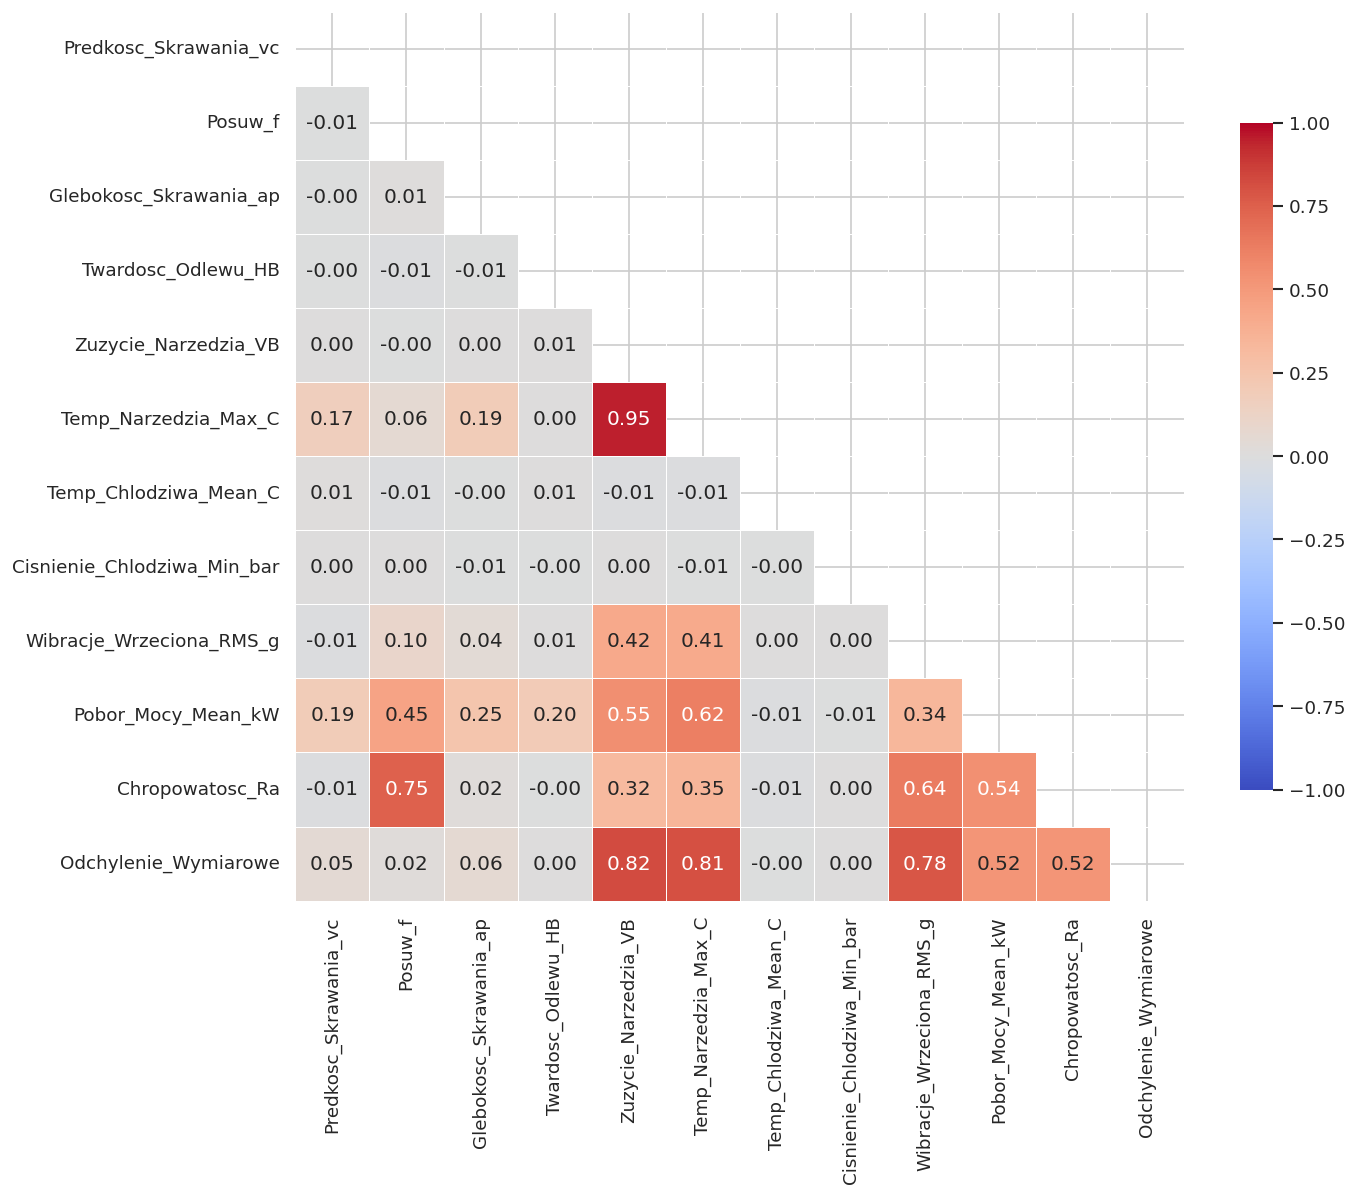

Generowanie wykresów zależności...


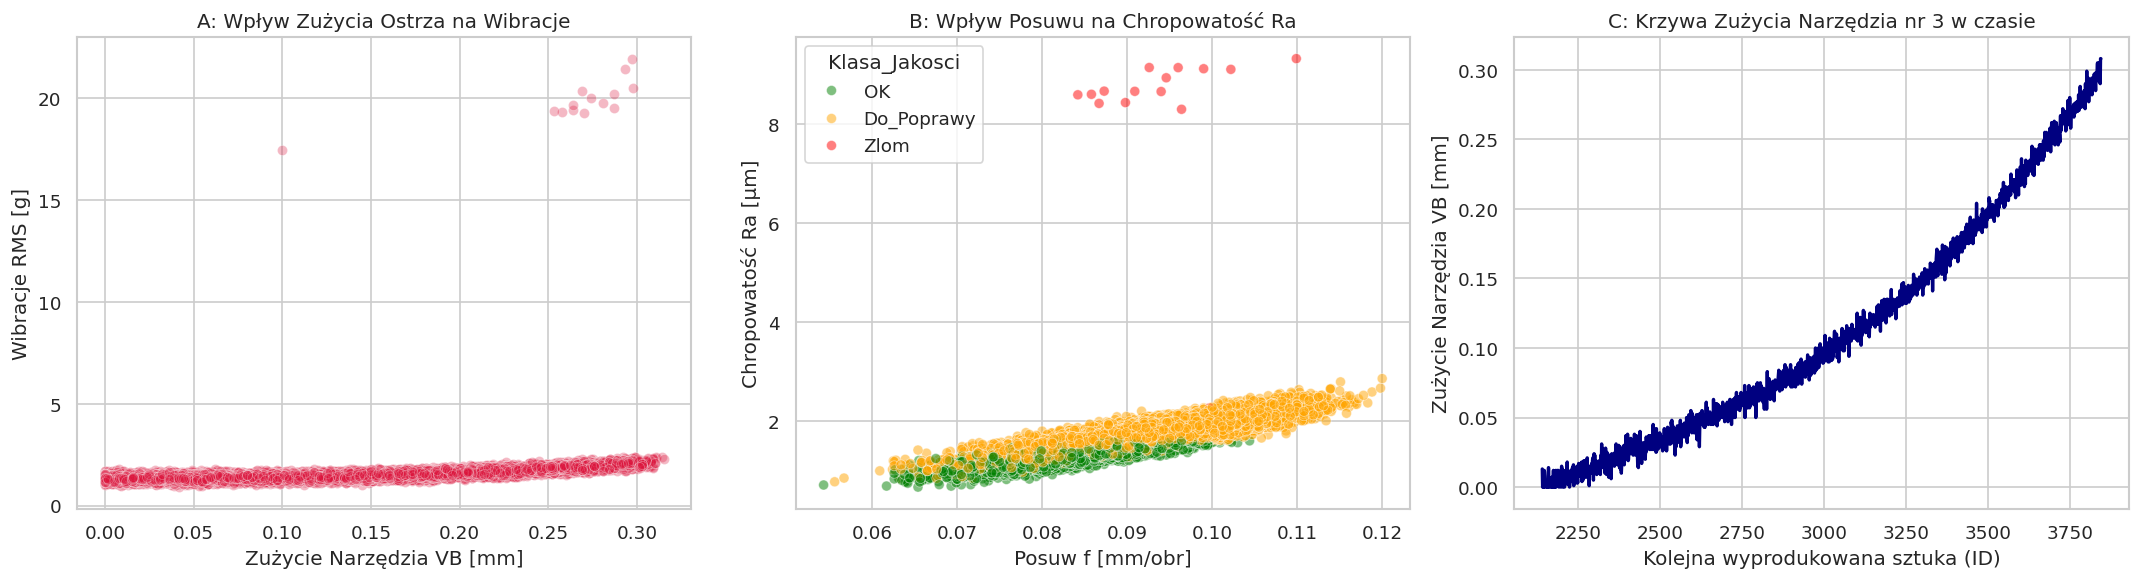

EDA zakończone. Wykresy zapisane.
Wczytywanie danych...
Generowanie rozkładu zmiennych w klasach jakości


/tmp/ipykernel_5816/199831039.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Klasa_Jakosci', y='Wibracje_Wrzeciona_RMS_g',
/tmp/ipykernel_5816/199831039.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Klasa_Jakosci', y='Temp_Narzedzia_Max_C',
/tmp/ipykernel_5816/199831039.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Klasa_Jakosci', y='Zuzycie_Narzedzia_VB',


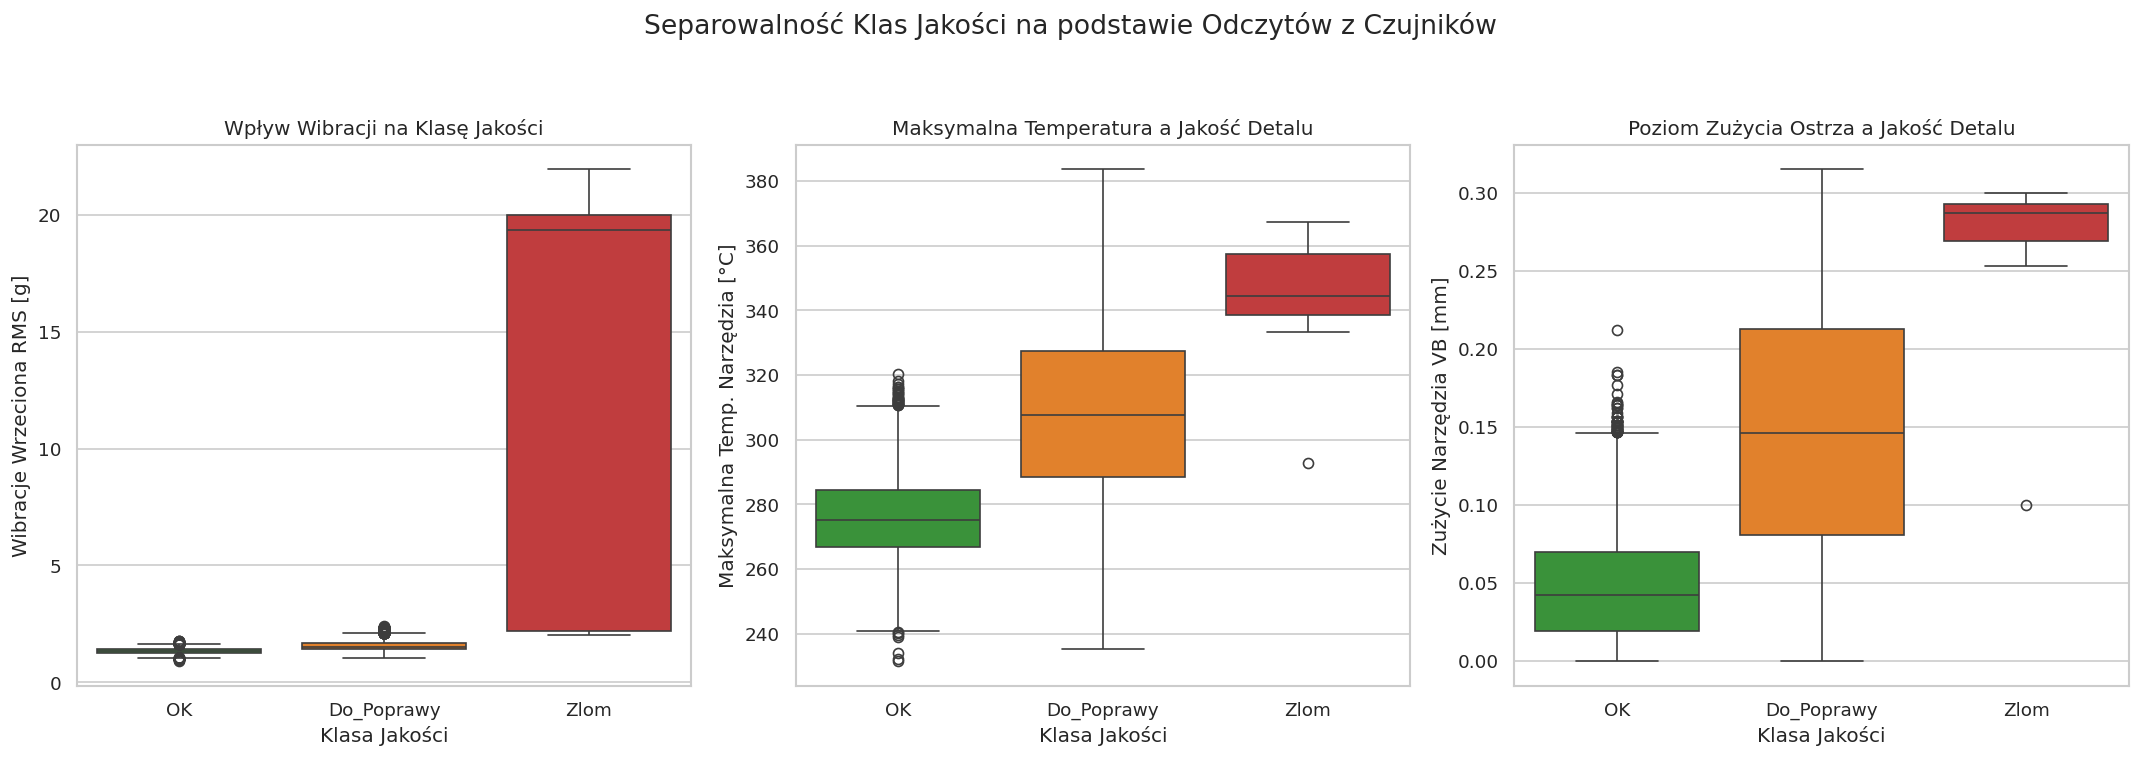

Generowanie macierzy korelacji Spearmana


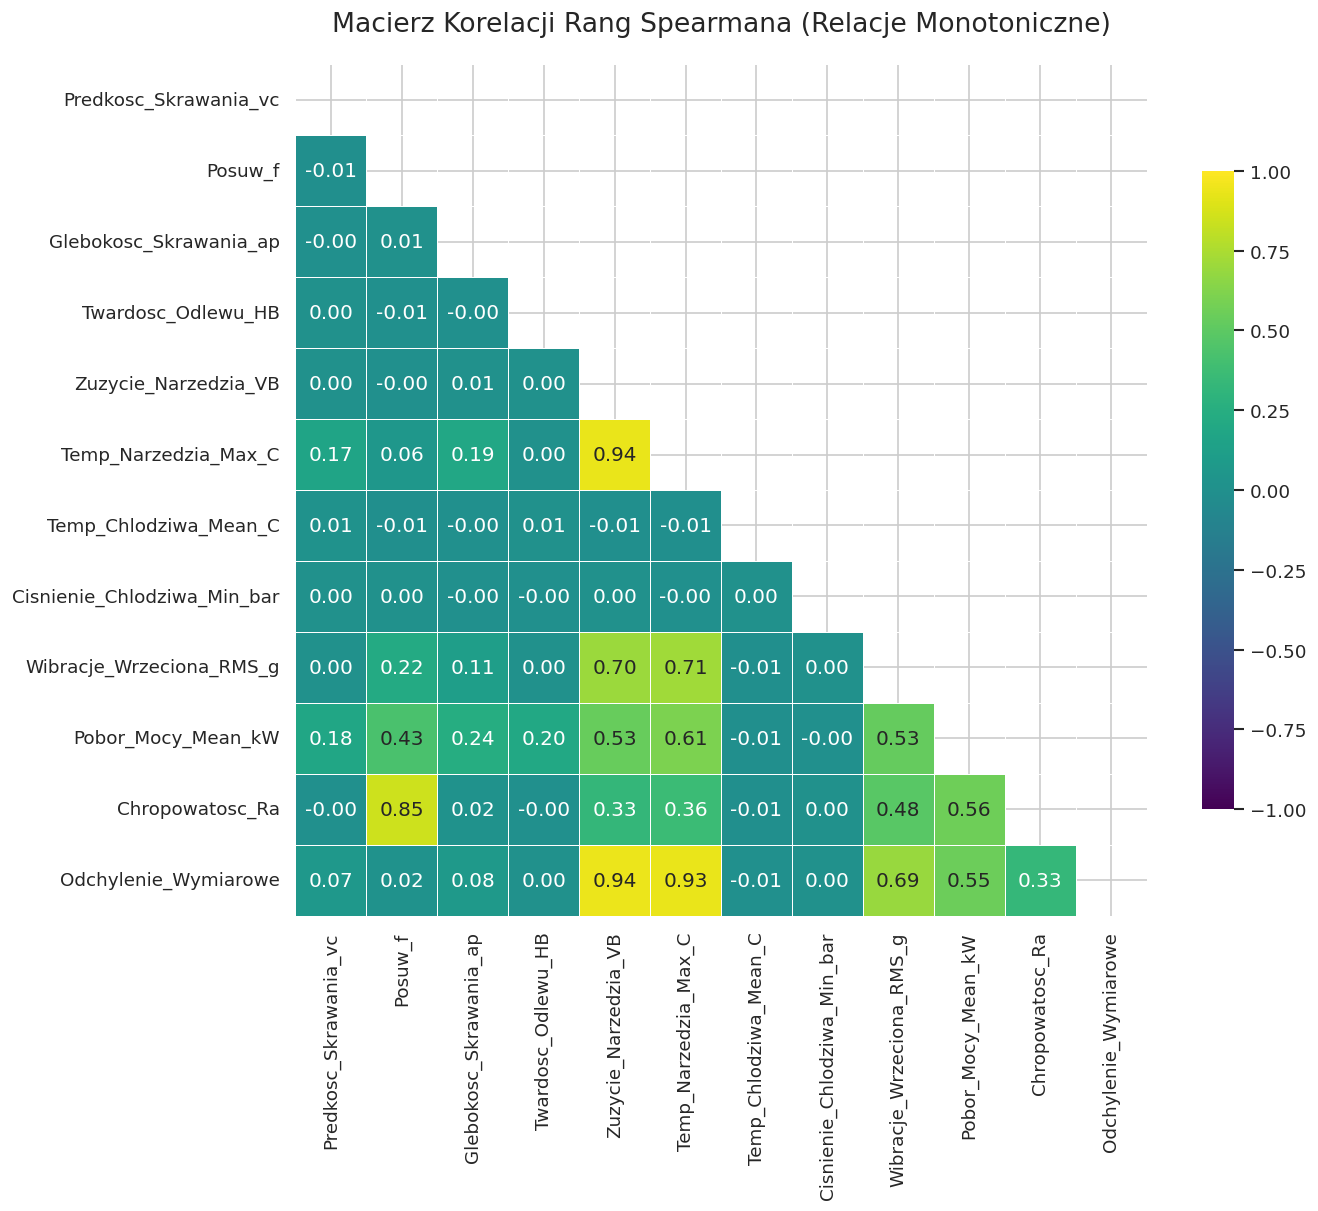

Generowanie wykresów zakończone!


In [16]:
perform_eda()
generate_eda()